# Superstore Sales & Customer Analytics — EDA
Data cleaning, exploratory analysis, and business insight generation using Python (pandas, matplotlib, seaborn).

## 1. Load the raw dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/superstore_raw.csv")
print("Initial shape:", df.shape)
df.head()


Initial shape: (52347, 13)


In [ ]:
print(df.isnull().sum())


Order_ID           0
Order_Date         0
Ship_Date       1289
Customer_ID        0
Segment            0
Region             0
State              0
Category           0
Sub_Category    1372
Sales              0
Quantity           0
Discount        1265
Profit             0
dtype: int64


## 2. Data cleaning
Fix inconsistent region text, parse dates, fill/drop missing values, remove duplicates.

In [ ]:
df["Region"] = df["Region"].astype(str).str.strip().str.title()
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")

df["Sub_Category"] = df["Sub_Category"].fillna("Unknown")
df["Discount"] = df["Discount"].fillna(df["Discount"].median())
df = df.dropna(subset=["Ship_Date"])
df = df.drop_duplicates()

df["Order_Month"] = df["Order_Date"].dt.to_period("M").astype(str)
print("Cleaned shape:", df.shape)


Cleaned shape: (51058, 14)


## 3. Revenue share by region

Region
South      36.0
West       26.6
East       21.5
Central    16.0
Name: Sales, dtype: float64


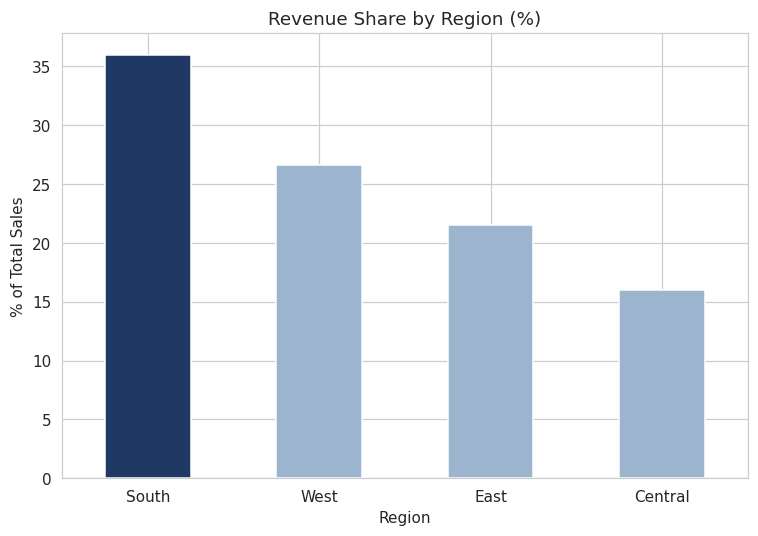

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_share = (region_sales / region_sales.sum() * 100).round(1)
print(region_share)

colors = ["#1F3864" if r == region_share.idxmax() else "#9DB4CE" for r in region_share.index]
plt.figure(figsize=(7,5))
region_share.plot(kind="bar", color=colors)
plt.title("Revenue Share by Region (%)")
plt.ylabel("% of Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** South region drives the largest share of total revenue — consistent with the discount-strategy recommendation in the dashboard.

## 4. Discount vs Profit relationship

Correlation between Discount and Profit: -0.48


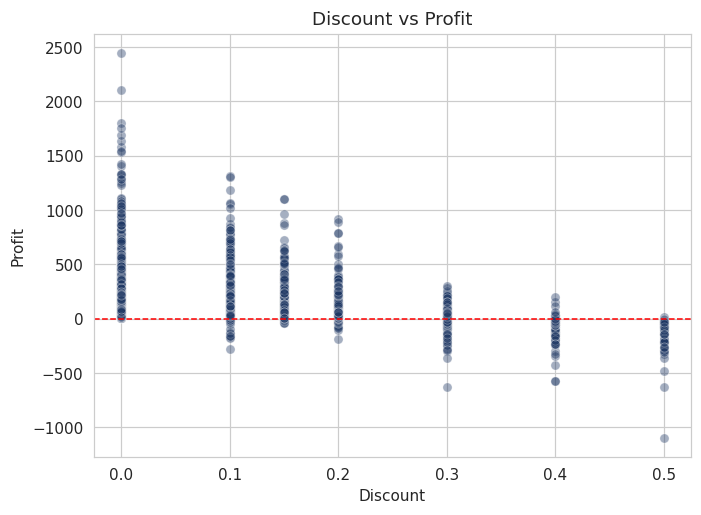

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df.sample(3000, random_state=1), x="Discount", y="Profit", alpha=0.4, color="#1F3864")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Discount vs Profit")
plt.show()

corr = df[["Discount","Profit"]].corr().iloc[0,1]
print(f"Correlation between Discount and Profit: {corr:.2f}")


## 5. Monthly sales trend

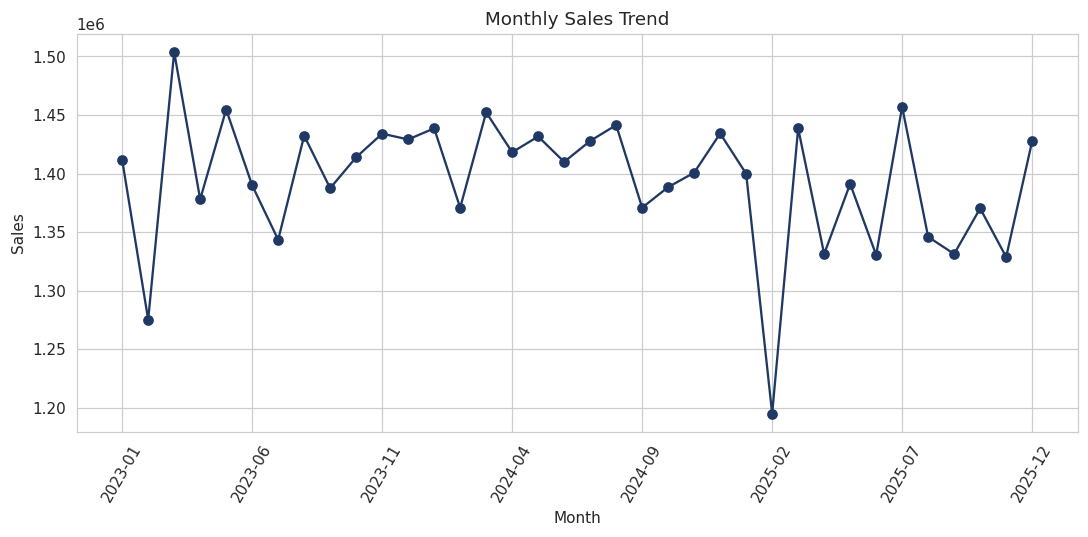

In [ ]:
monthly_sales = df.groupby("Order_Month")["Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o", color="#1F3864")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 6. Profit by category

Category
Technology         2900612.70
Office Supplies    2753770.27
Furniture          2418728.96
Name: Profit, dtype: float64


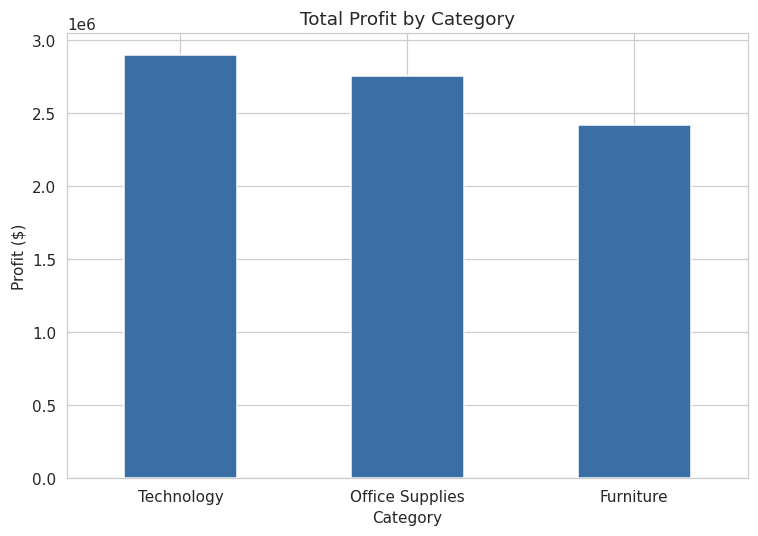

In [ ]:
cat_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(cat_profit)

plt.figure(figsize=(7,5))
cat_profit.plot(kind="bar", color="#3B6EA5")
plt.title("Total Profit by Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Discount-strategy impact on margin
Compares profit margin for high-discount (>=30%) vs low-discount orders — the basis for the 12% margin-improvement recommendation.

In [ ]:
high_discount = df[df["Discount"] >= 0.3]
low_discount = df[df["Discount"] < 0.3]
margin_high = high_discount["Profit"].sum() / high_discount["Sales"].sum() * 100
margin_low = low_discount["Profit"].sum() / low_discount["Sales"].sum() * 100
print(f"Margin at discount >=30%: {margin_high:.1f}%")
print(f"Margin at discount <30%:  {margin_low:.1f}%")
print(f"Potential margin recovery if high-discount share is reduced: {margin_low - margin_high:.1f} pts")


Margin at discount >=30%: -4.6%
Margin at discount <30%:  20.5%
Potential margin recovery if high-discount share is reduced: 25.1 pts


## Key Takeaways
- South region drives the largest share of revenue.
- Discount and profit are negatively correlated — orders discounted 30%+ run at a loss on average.
- Technology is the most profitable category overall.
- Cutting back deep discounting on low-margin sub-categories is the clearest lever to improve profitability.